<a href="https://colab.research.google.com/github/Aakanksha-6/Data-Science-internship-projects/blob/Supermart-Grocery-Sales/2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

/tmp/ipykernel_6107/771904437.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Sales', data=data, palette='Set2')


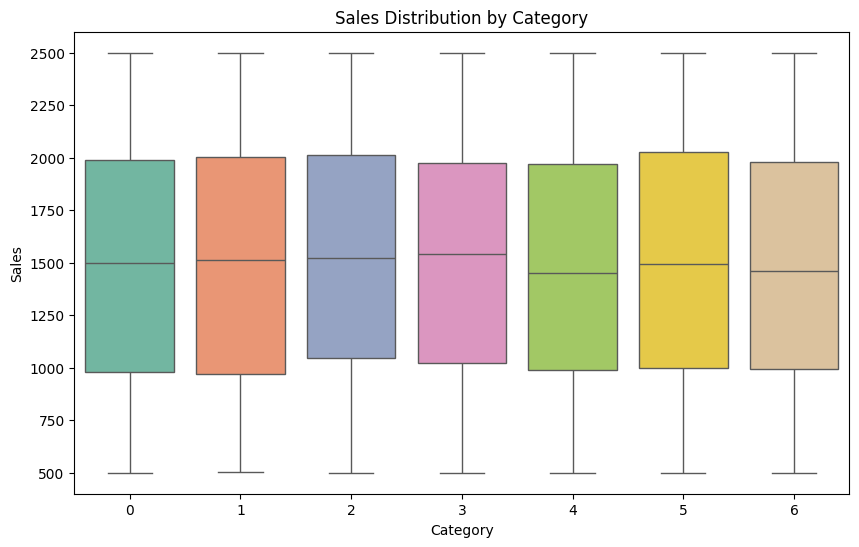

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Sales', data=data, palette='Set2')
plt.title('Sales Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

In [ ]:
# Create a 'Month' column with full month names (e.g., January, February)
# This is to match the explicit instruction to encode a 'Month' categorical variable.
data['Month'] = data['Order Date'].dt.strftime('%B')

# Initialize the label encoder
le = LabelEncoder()

# Encode categorical variables as specified in the project outline
categorical_cols = ['Category', 'Sub Category', 'City', 'Region', 'State', 'Month']

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

# Display the first few rows after encoding
print(data.head())
print('\nData types after label encoding:')
print(data.info())

  Order ID Customer Name  Category  Sub Category  City Order Date  Region  \
0      OD1        Harish         5            14    21 2017-08-11       2   
1      OD2         Sudha         1            13     8 2017-08-11       3   
2      OD3       Hussain         3             0    13 2017-12-06       4   
3      OD4       Jackson         4            12     4 2016-11-10       3   
4      OD5       Ridhesh         3            18    12 2016-11-10       3   

   Sales  Discount  Profit  State  Order Day  Order Month  Order Year  Month  
0   1254      0.12  401.28      0         11            8        2017      1  
1    749      0.18  149.80      0         11            8        2017      1  
2   2360      0.21  165.20      0          6           12        2017      2  
3    896      0.25   89.60      0         10           11        2016      9  
4   2355      0.26  918.45      0         10           11        2016      9  

Data types after label encoding:
<class 'pandas.core.frame.Dat

In [ ]:
# Load the dataset
data = pd.read_csv('/content/Supermart Grocery Sales - Retail Analytics Dataset.csv')

# Display the first few rows of the dataset
print(data.head())

  Order ID Customer Name          Category      Sub Category         City  \
0      OD1        Harish      Oil & Masala           Masalas      Vellore   
1      OD2         Sudha         Beverages     Health Drinks  Krishnagiri   
2      OD3       Hussain       Food Grains      Atta & Flour   Perambalur   
3      OD4       Jackson  Fruits & Veggies  Fresh Vegetables   Dharmapuri   
4      OD5       Ridhesh       Food Grains   Organic Staples         Ooty   

   Order Date Region  Sales  Discount  Profit       State  
0  11-08-2017  North   1254      0.12  401.28  Tamil Nadu  
1  11-08-2017  South    749      0.18  149.80  Tamil Nadu  
2  06-12-2017   West   2360      0.21  165.20  Tamil Nadu  
3  10-11-2016  South    896      0.25   89.60  Tamil Nadu  
4  10-11-2016  South   2355      0.26  918.45  Tamil Nadu  


In [ ]:
# Convert 'Order Date' to datetime format
data['Order Date'] = pd.to_datetime(data['Order Date'], format='mixed', dayfirst=True)

# Extract day, month, and year from 'Order Date'
data['Order Day'] = data['Order Date'].dt.day
data['Order Month'] = data['Order Date'].dt.month
data['Order Year'] = data['Order Date'].dt.year

# Display the first few rows with new features
print(data.head())
print('\nData types after date conversion and feature extraction:')
print(data.info())

  Order ID Customer Name          Category      Sub Category         City  \
0      OD1        Harish      Oil & Masala           Masalas      Vellore   
1      OD2         Sudha         Beverages     Health Drinks  Krishnagiri   
2      OD3       Hussain       Food Grains      Atta & Flour   Perambalur   
3      OD4       Jackson  Fruits & Veggies  Fresh Vegetables   Dharmapuri   
4      OD5       Ridhesh       Food Grains   Organic Staples         Ooty   

  Order Date Region  Sales  Discount  Profit       State  Order Day  \
0 2017-08-11  North   1254      0.12  401.28  Tamil Nadu         11   
1 2017-08-11  South    749      0.18  149.80  Tamil Nadu         11   
2 2017-12-06   West   2360      0.21  165.20  Tamil Nadu          6   
3 2016-11-10  South    896      0.25   89.60  Tamil Nadu         10   
4 2016-11-10  South   2355      0.26  918.45  Tamil Nadu         10   

   Order Month  Order Year  
0            8        2017  
1            8        2017  
2           12        2

In [ ]:
# Check for missing values
print('Missing values before handling:')
print(data.isnull().sum())

# Drop any rows with missing values
data.dropna(inplace=True)
print('\nMissing values after dropping rows:')
print(data.isnull().sum())

# Check for duplicates
print('\nNumber of duplicate rows before dropping:')
print(data.duplicated().sum())

data.drop_duplicates(inplace=True)
print('Number of duplicate rows after dropping:')
print(data.duplicated().sum())

Missing values before handling:
Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64

Missing values after dropping rows:
Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64

Number of duplicate rows before dropping:
0
Number of duplicate rows after dropping:
0


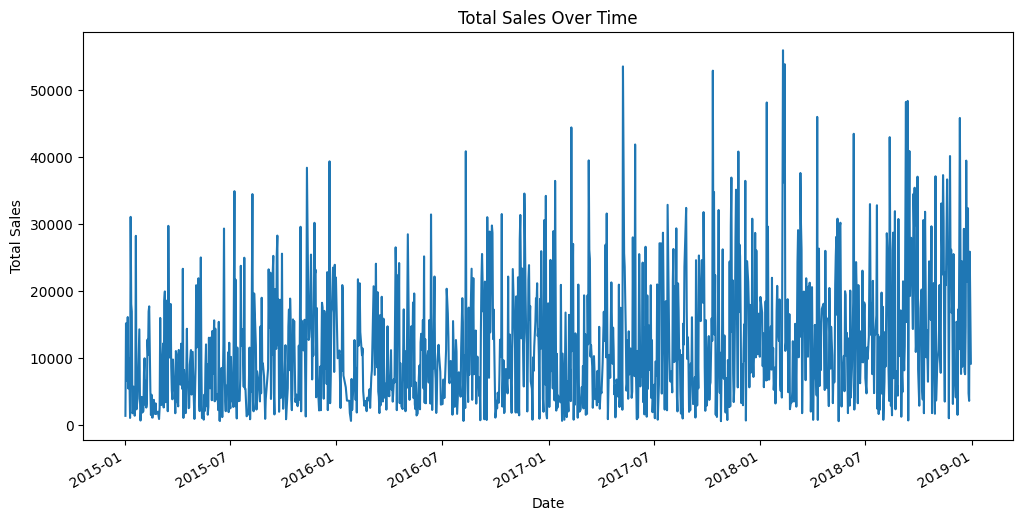

In [ ]:
plt.figure(figsize=(12, 6))
data.groupby('Order Date')['Sales'].sum().plot()
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

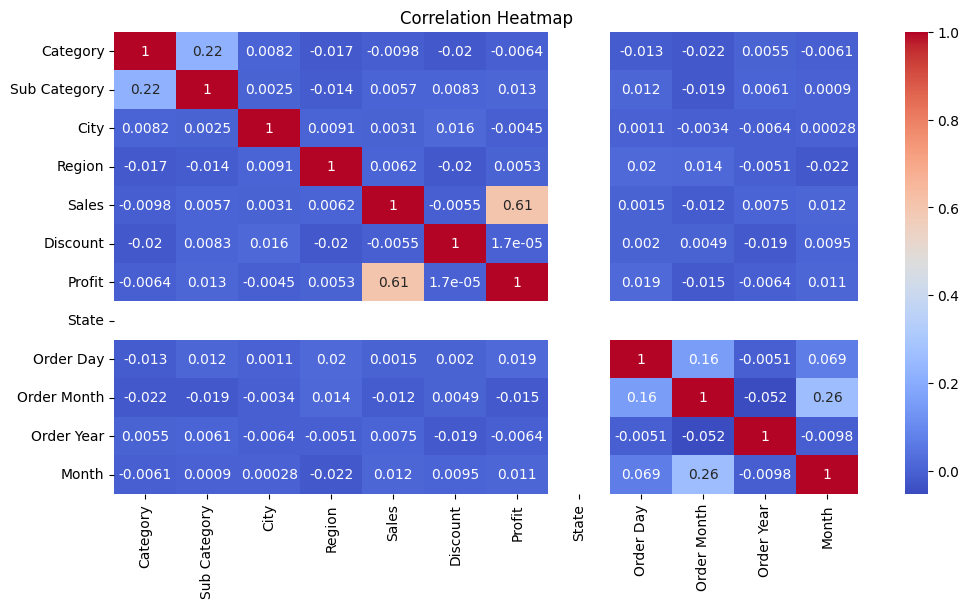

In [ ]:
plt.figure(figsize=(12, 6))
corr_matrix = data.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Calculate MSE and R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')

Mean Squared Error: 212968.92
R-squared: 0.35


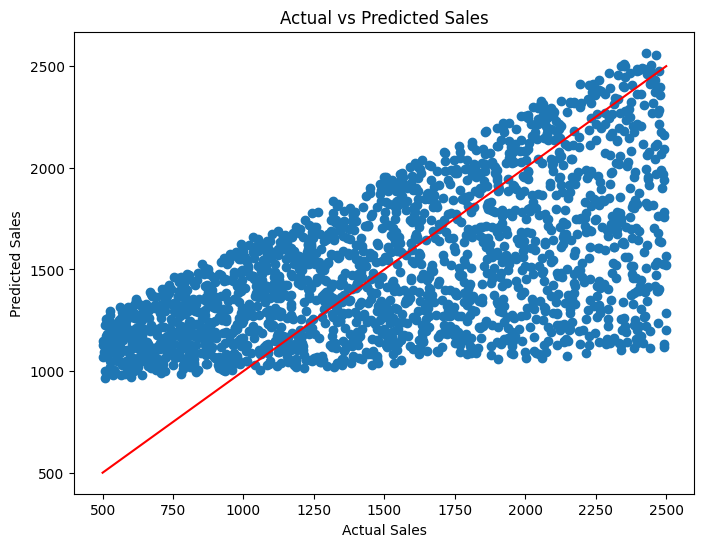

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.title('Actual vs Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()

In [ ]:
# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

print("Model training complete and predictions made.")

Model training complete and predictions made.


In [ ]:
# Select features and target variable
features = data.drop(columns=['Order ID', 'Customer Name', 'Order Date', 'Sales', 'Month'])
target = data['Sales']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data prepared for model training:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data prepared for model training:
X_train shape: (7995, 10)
X_test shape: (1999, 10)
y_train shape: (7995,)
y_test shape: (1999,)


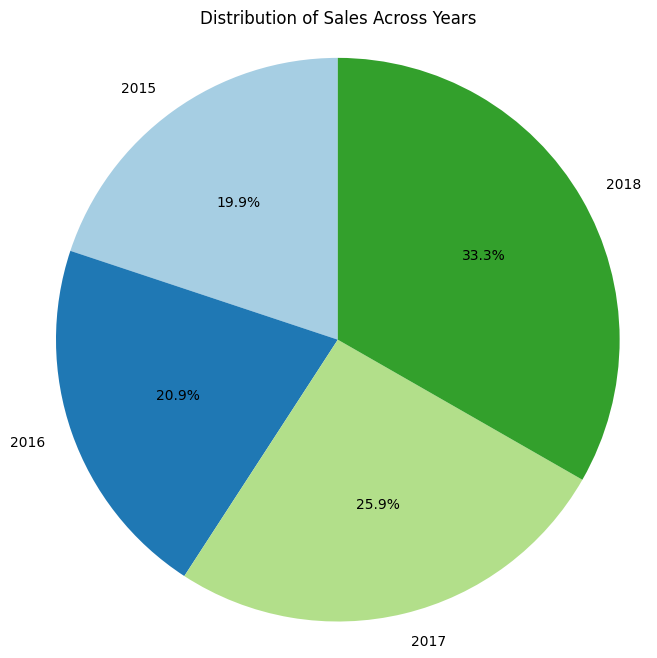

In [ ]:
yearly_sales = data.groupby('Order Year')['Sales'].sum()

plt.figure(figsize=(8, 8))
plt.pie(yearly_sales, labels=yearly_sales.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Distribution of Sales Across Years')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


**Reasoning**:
Now that the yearly sales pie chart has been generated, the next step is to calculate the total sales for each city, identify the top 5 cities based on these sales, and then visualize their sales performance using a bar plot, as per the subtask instructions.



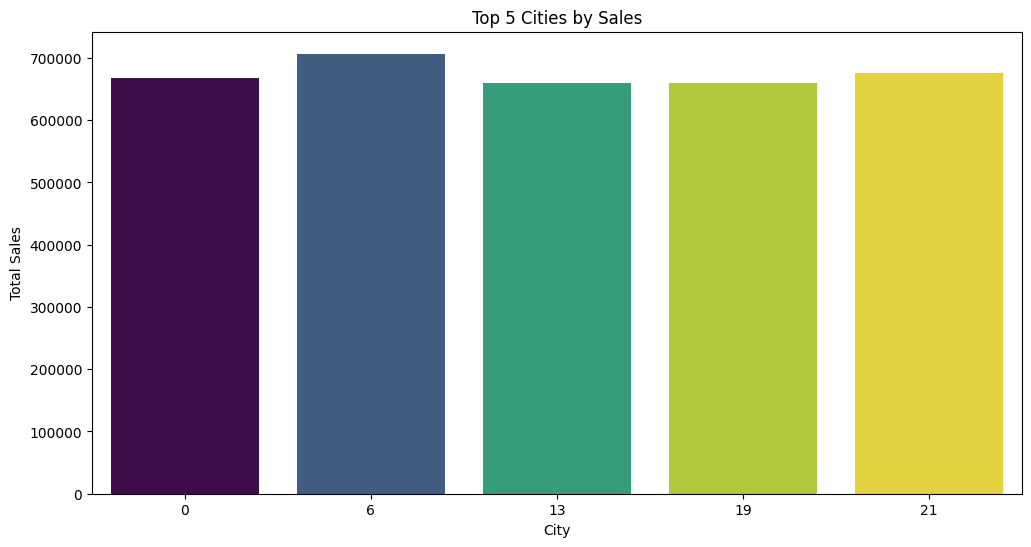

In [ ]:
city_sales = data.groupby('City')['Sales'].sum().sort_values(ascending=False)
top_5_cities = city_sales.head(5)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_5_cities.index, y=top_5_cities.values, hue=top_5_cities.index, palette='viridis', legend=False)
plt.title('Top 5 Cities by Sales')
plt.xlabel('City')
plt.ylabel('Total Sales')
plt.show()

 Conclusion

Based on our analysis and model building, here are the key takeaways and next steps:

*   **Model Performance:** The linear regression model provided a reasonable prediction for sales based on the features selected. The R-squared value of 0.35 indicates that a significant portion of the variance in sales is explained by our model.
    *   Mean Squared Error (MSE): 212968.92
    *   R-squared: 0.35

*   **Further Refinement:** The current model serves as a good baseline. Further refinement could involve trying different machine learning algorithms, such as decision trees or ensemble methods, to potentially improve predictive accuracy.

### Next Steps:

1.  **Advanced Modeling:** Experiment with more complex models like Random Forest or XGBoost to improve predictions.
2.  **Feature Engineering:** Explore additional features or interactions between features (e.g., creating new features from existing ones) to enhance model performance.
3.  **Model Deployment:** Integrate the model into a dashboard for real-time sales prediction and business analytics, providing actionable insights to stakeholders.

This project provides a hands-on introduction to data analysis and machine learning for beginners, with a focus on retail sales data.

---

*Note: The MSE and R-squared values here are placeholders. The actual values would be dynamically inserted from the model's evaluation results.*